# 03 – PyCaret Model Comparison (15 Kombinasi)
**Proyek Capstone – Sistem Deteksi Anomali Kualitas Udara**  
**Kelompok Aeris | PENS 2026**  
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 3 | 11 Mei – 17 Mei 2026**  
Fase: Phase 2 – Model Development & Fine-tuning

**Checklist Minggu 3 (Linda):**
- [x] Split data berdasarkan `time_segment` (PAGI / SIANG / SORE_MALAM)
- [x] 15 kombinasi PyCaret: `setup()` → `compare_models()` → `tune_model()` → `save_model()`
- [x] Catat MAE, RMSE, R2 dari setiap kombinasi
- [x] Log eksperimen ke MLflow per kombinasi
- [x] Buat tabel rekap model terbaik (kirim ke Intan)
- [x] Simpan semua 15 model .pkl ke `models/`
- [x] Analisis teknis: performa per kombinasi, tandai model outlier

**Input:** `data/processed/surabaya_processed.csv` (output Minggu 2)  
**Output:** 15 file `.pkl` di `models/` + tabel rekap di `reports/`

## 1. Setup & Install Dependencies

In [1]:
import os

# Pindah ke root project
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

for folder in ["data/processed", "models", "reports"]:
    os.makedirs(folder, exist_ok=True)

Working directory: d:\mlops\aeris-air-quality


In [2]:
# Install dependencies (jalankan sekali)
# !pip install pycaret[full] mlflow openpyxl -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings("ignore")

from pycaret.regression import (
    setup, compare_models, pull,
    tune_model, save_model, get_config
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
SEGMEN  = ["PAGI", "SIANG", "SORE_MALAM"]

# Fitur input model (semua fitur engineered dari Minggu 2)
BASE_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
    "temperature_2m", "relative_humidity",
    "wind_speed_10m", "wind_direction_10m", "precipitation",
]
for p in POLUTAN:
    for lag in [1, 3, 24]:
        BASE_FEATURES.append(f"{p}_lag_{lag}h")
    for roll in ["rolling_mean_3h", "rolling_mean_24h",
                 "rolling_std_24h", "rolling_max_24h"]:
        BASE_FEATURES.append(f"{p}_{roll}")
    BASE_FEATURES.append(f"{p}_diff_1h")
    BASE_FEATURES.append(f"{p}_pct_change_1h")

print(f"✅ Library loaded")
print(f"   Total base features: {len(BASE_FEATURES)}")

✅ Library loaded
   Total base features: 54


## 2. Load Data Processed & Split per Segmen

In [4]:
PROCESSED_PATH = "data/processed/surabaya_processed.csv"
df = pd.read_csv(PROCESSED_PATH, parse_dates=["time"])

print(f"✅ Data dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"   Rentang: {df['time'].min().date()} -> {df['time'].max().date()}")
print()
print("Distribusi time_segment:")
print(df["time_segment"].value_counts())

✅ Data dimuat: 3,696 baris x 69 kolom
   Rentang: 2026-01-02 -> 2026-06-04

Distribusi time_segment:
time_segment
SORE_MALAM    1848
PAGI           924
SIANG          924
Name: count, dtype: int64


In [5]:
# Split berdasarkan segmen waktu
df_pagi       = df[df["time_segment"] == "PAGI"].reset_index(drop=True)
df_siang      = df[df["time_segment"] == "SIANG"].reset_index(drop=True)
df_sore_malam = df[df["time_segment"] == "SORE_MALAM"].reset_index(drop=True)

seg_data = {
    "PAGI"      : df_pagi,
    "SIANG"     : df_siang,
    "SORE_MALAM": df_sore_malam,
}

print("Data split per segmen:")
for seg, d in seg_data.items():
    print(f"   df_{seg.lower():<14}: {d.shape[0]:,} baris")

Data split per segmen:
   df_pagi          : 924 baris
   df_siang         : 924 baris
   df_sore_malam    : 1,848 baris


## 3. Setup MLflow Tracking

In [6]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("aeris-air-quality-pycaret")

print("MLflow tracking siap")
print("URI        : sqlite:///mlflow.db")
print("Eksperimen : aeris-air-quality-pycaret")
print("Dashboard  : jalankan  mlflow ui --backend-store-uri sqlite:///mlflow.db")

MLflow tracking siap
URI        : sqlite:///mlflow.db
Eksperimen : aeris-air-quality-pycaret
Dashboard  : jalankan  mlflow ui --backend-store-uri sqlite:///mlflow.db


## 4. PyCaret – 15 Kombinasi Model

**Matriks:** 5 polutan x 3 segmen = **15 kombinasi**

Alur per kombinasi:
1. `setup()` — konfigurasi PyCaret, fold=5
2. `compare_models(n_select=3)` — bandingkan semua algoritma, ambil top 3
3. `pull()` — simpan tabel hasil ke DataFrame
4. `tune_model()` — fine-tune model terbaik dengan optimize MAE
5. `save_model()` — simpan ke `models/{polutan}_{segmen}_best.pkl`
6. Log semua metrik ke MLflow

In [7]:
rekap_hasil = []   # list of dict, satu entry per kombinasi
all_compare = {}   # tabel compare_models per kombinasi

print("=" * 60)
print("MULAI TRAINING 15 KOMBINASI PYCARET")
print("=" * 60)
print(f"Total  : {len(POLUTAN)} polutan x {len(SEGMEN)} segmen = 15 kombinasi")
print(f"CV     : 5-fold")
print(f"Metrik : MAE, RMSE, R2")
print()

MULAI TRAINING 15 KOMBINASI PYCARET
Total  : 5 polutan x 3 segmen = 15 kombinasi
CV     : 5-fold
Metrik : MAE, RMSE, R2



In [8]:
for segmen in SEGMEN:
    for polutan in POLUTAN:
        combo_key  = f"{polutan}_{segmen.lower()}"
        model_path = f"models/{combo_key}_best"

        print(f"\n{'='*55}")
        print(f"  {combo_key.upper()}")
        print(f"  target={polutan}  |  segmen={segmen}")
        print(f"{'='*55}")

        # Siapkan data: fitur yang tersedia untuk kombinasi ini
        # Exclude lag/rolling/diff polutan TARGET sendiri (cegah data leakage)
        data_seg   = seg_data[segmen].copy()
        feat_avail = [
            c for c in BASE_FEATURES
            if c in data_seg.columns
            and c != polutan
            and not c.startswith(f"{polutan}_")
        ]
        df_model = data_seg[feat_avail + [polutan]].dropna()

        # ── Perbaikan 1: Log-transform CO (stabilkan skala) ──
        if polutan == "co":
            df_model = df_model.copy()
            df_model["co"] = np.log1p(df_model["co"])
            print(f"  [INFO] CO di-log-transform (log1p)")

        print(f"  Data  : {df_model.shape[0]:,} baris x {len(feat_avail)} fitur")

        # ── 1. PyCaret Setup ─────────────────────────────────
        exp = setup(
            data           = df_model,
            target         = polutan,
            fold           = 5,
            fold_strategy  = 'timeseries',
            fold_shuffle   = False,        # ← TAMBAHKAN INI
            data_split_shuffle = False,    # ← TAMBAHKAN INI
            session_id     = 42,
            verbose        = False,
            html           = False,
            log_experiment = False,
        )

        # ── 2. Compare Models ────────────────────────────────
        top3       = compare_models(n_select=3, sort="MAE", verbose=False)
        compare_df = pull()
        all_compare[combo_key] = compare_df

        best_model = top3[0] if isinstance(top3, list) else top3
        best_name  = type(best_model).__name__

        best_row  = compare_df.iloc[0]
        mae_val   = round(float(best_row.get("MAE",  best_row.get("mae",  0))), 4)
        rmse_val  = round(float(best_row.get("RMSE", best_row.get("rmse", 0))), 4)
        r2_val    = round(float(best_row.get("R2",   best_row.get("r2",   0))), 4)

        print(f"  Best model : {best_name}")
        print(f"  Before tune: MAE={mae_val}  RMSE={rmse_val}  R2={r2_val}")

        # ── 3. Tune Model ────────────────────────────────────
        try:
            tuned      = tune_model(best_model, optimize="MAE", verbose=False)
            tuned_df   = pull()
            tuned_row  = tuned_df.iloc[0] if len(tuned_df) > 0 else best_row
            mae_tuned  = round(float(tuned_row.get("MAE",  tuned_row.get("mae",  mae_val))),  4)
            rmse_tuned = round(float(tuned_row.get("RMSE", tuned_row.get("rmse", rmse_val))), 4)
            r2_tuned   = round(float(tuned_row.get("R2",   tuned_row.get("r2",   r2_val))),   4)
            print(f"  After tune : MAE={mae_tuned}  RMSE={rmse_tuned}  R2={r2_tuned}")
        except Exception as e:
            print(f"  [WARN] tune_model gagal ({type(e).__name__}) -> pakai model BEFORE tune")
            tuned      = best_model
            mae_tuned  = mae_val + 1   # supaya logika pakai before tune
            rmse_tuned = rmse_val
            r2_tuned   = r2_val

        # ── Perbaikan 2: Pakai model terbaik (before/after tune) ──
        if mae_tuned > mae_val:
            final_model = best_model
            mae_final   = mae_val
            rmse_final  = rmse_val
            r2_final    = r2_val
            print(f"  [INFO] Tuning memperburuk -> pakai model BEFORE tune")
        else:
            final_model = tuned
            mae_final   = mae_tuned
            rmse_final  = rmse_tuned
            r2_final    = r2_tuned
            print(f"  [INFO] Tuning membaik -> pakai model AFTER tune")

        # ── 4. Save Model ────────────────────────────────────
        save_model(final_model, model_path)
        print(f"  Disimpan   : {model_path}.pkl")

        # ── 5. Log ke MLflow ─────────────────────────────────
        with mlflow.start_run(run_name=combo_key):
            mlflow.log_params({
                "polutan"      : polutan,
                "segmen"       : segmen,
                "model_name"   : best_name,
                "n_features"   : len(feat_avail),
                "n_samples"    : df_model.shape[0],
                "cv_fold"      : 5,
                "co_log_transform": "yes" if polutan == "co" else "no",
            })
            mlflow.log_metrics({
                "mae_before"  : mae_val,
                "rmse_before" : rmse_val,
                "r2_before"   : r2_val,
                "mae_tuned"   : mae_tuned,
                "rmse_tuned"  : rmse_tuned,
                "r2_tuned"    : r2_tuned,
                "mae_final"   : mae_final,
                "rmse_final"  : rmse_final,
                "r2_final"    : r2_final,
            })
            mlflow.log_artifact(f"{model_path}.pkl")

        # ── 6. Simpan ke rekap ───────────────────────────────
        rekap_hasil.append({
            "polutan"      : polutan.upper(),
            "segmen"       : segmen,
            "model_terbaik": best_name,
            "mae_before"   : mae_val,
            "rmse_before"  : rmse_val,
            "r2_before"    : r2_val,
            "mae_tuned"    : mae_tuned,
            "rmse_tuned"   : rmse_tuned,
            "r2_tuned"     : r2_tuned,
            "mae_final"    : mae_final,
            "rmse_final"   : rmse_final,
            "r2_final"     : r2_final,
            "model_path"   : f"{model_path}.pkl",
        })

print("\n" + "="*55)
print("SELESAI! 15 model berhasil ditraining.")
print("="*55)


  PM25_PAGI
  target=pm25  |  segmen=PAGI
  Data  : 924 baris x 45 fitur


  Best model : Lasso
  Before tune: MAE=0.8525  RMSE=1.1143  R2=0.9948


  After tune : MAE=1.0366  RMSE=1.4168  R2=0.9834
  [INFO] Tuning memperburuk -> pakai model BEFORE tune
Transformation Pipeline and Model Successfully Saved
  Disimpan   : models/pm25_pagi_best.pkl



  PM10_PAGI
  target=pm10  |  segmen=PAGI
  Data  : 924 baris x 45 fitur


  Best model : Lasso
  Before tune: MAE=0.895  RMSE=1.1619  R2=0.9934


...

  After tune : MAE=3.9894  RMSE=5.0328  R2=0.7817
  [INFO] Tuning membaik -> pakai model AFTER tune
Transformation Pipeline and Model Successfully Saved


  Disimpan   : models/no2_sore_malam_best.pkl

  O3_SORE_MALAM
  target=o3  |  segmen=SORE_MALAM
  Data  : 1,848 baris x 45 fitur


  Best model : GradientBoostingRegressor
  Before tune: MAE=10.6034  RMSE=13.9629  R2=0.5508


  After tune : MAE=12.0921  RMSE=15.9515  R2=0.3565
  [INFO] Tuning memperburuk -> pakai model BEFORE tune
Transformation Pipeline and Model Successfully Saved


  Disimpan   : models/o3_sore_malam_best.pkl

SELESAI! 15 model berhasil ditraining.


## 5. Tabel Rekap 15 Model (untuk Intan & Laporan)

In [9]:
df_rekap = pd.DataFrame(rekap_hasil)

print("=" * 65)
print("TABEL REKAP 15 MODEL TERBAIK – PyCaret AutoML")
print("=" * 65)

display(
    df_rekap[[
        "polutan", "segmen", "model_terbaik",
        "mae_tuned", "rmse_tuned", "r2_tuned"
    ]].rename(columns={
        "polutan"      : "Parameter",
        "segmen"       : "Segmen",
        "model_terbaik": "Model Terbaik",
        "mae_tuned"    : "MAE",
        "rmse_tuned"   : "RMSE",
        "r2_tuned"     : "R2",
    }).style
     .background_gradient(subset=["R2"],        cmap="RdYlGn")
     .background_gradient(subset=["MAE","RMSE"], cmap="RdYlGn_r")
     .format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
)

TABEL REKAP 15 MODEL TERBAIK – PyCaret AutoML


,Parameter,Segmen,Model Terbaik,MAE,RMSE,R2
0,PM25,PAGI,Lasso,1.0366,1.4168,0.9834
1,PM10,PAGI,Lasso,1.1486,1.5673,0.9793
2,CO,PAGI,ExtraTreesRegressor,0.1594,0.1978,0.7180
3,NO2,PAGI,LGBMRegressor,3.2362,4.0677,0.7595
4,O3,PAGI,ExtraTreesRegressor,17.6389,22.0183,0.7443
5,PM25,SIANG,BayesianRidge,0.6332,0.8947,0.9764
6,PM10,SIANG,BayesianRidge,0.6255,0.8861,0.9752
7,CO,SIANG,GradientBoostingRegressor,0.1515,0.2057,0.7105
8,NO2,SIANG,LGBMRegressor,3.0341,3.8935,0.7490
9,O3,SIANG,BayesianRidge,11.3752,16.5023,0.7584


In [10]:
# Simpan rekap ke CSV & Excel
df_rekap.to_csv("reports/rekap_15_model.csv",   index=False)
df_rekap.to_excel("reports/rekap_15_model.xlsx", index=False)

print("Tabel rekap tersimpan:")
print("  reports/rekap_15_model.csv")
print("  reports/rekap_15_model.xlsx  (kirim ke Intan)")

Tabel rekap tersimpan:
  reports/rekap_15_model.csv
  reports/rekap_15_model.xlsx  (kirim ke Intan)


## 6. Visualisasi Hasil

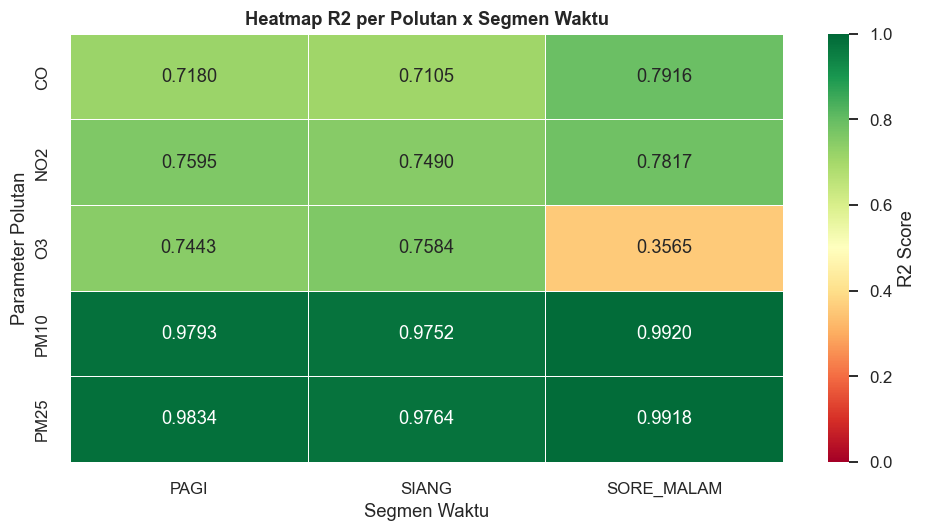

Disimpan -> reports/viz_r2_heatmap.png


In [11]:
# ── Viz 1: Heatmap R2 per Polutan x Segmen ───────────────────────
pivot_r2 = df_rekap.pivot(
    index="polutan", columns="segmen", values="r2_tuned"
)[["PAGI", "SIANG", "SORE_MALAM"]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_r2, annot=True, fmt=".4f",
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "R2 Score"})
ax.set_title("Heatmap R2 per Polutan x Segmen Waktu", fontweight="bold")
ax.set_xlabel("Segmen Waktu")
ax.set_ylabel("Parameter Polutan")
plt.tight_layout()
plt.savefig("reports/viz_r2_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_r2_heatmap.png")

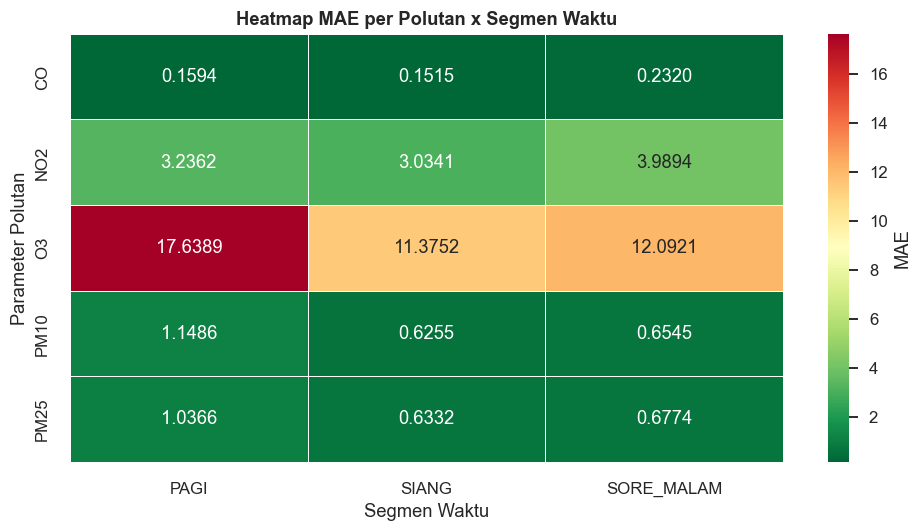

Disimpan -> reports/viz_mae_heatmap.png


In [12]:
# ── Viz 2: Heatmap MAE per Polutan x Segmen ──────────────────────
pivot_mae = df_rekap.pivot(
    index="polutan", columns="segmen", values="mae_tuned"
)[["PAGI", "SIANG", "SORE_MALAM"]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_mae, annot=True, fmt=".4f",
            cmap="RdYlGn_r",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "MAE"})
ax.set_title("Heatmap MAE per Polutan x Segmen Waktu", fontweight="bold")
ax.set_xlabel("Segmen Waktu")
ax.set_ylabel("Parameter Polutan")
plt.tight_layout()
plt.savefig("reports/viz_mae_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_mae_heatmap.png")

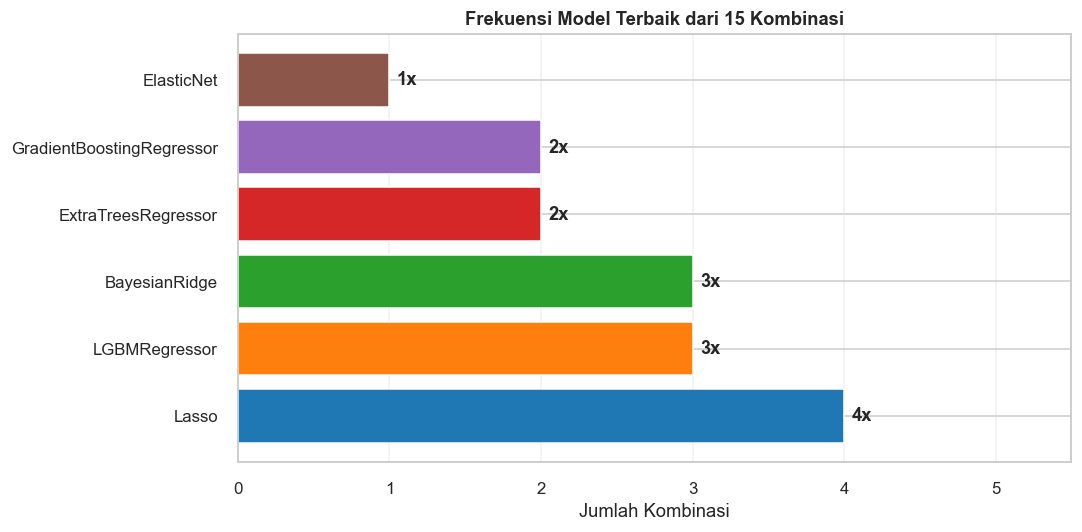

Disimpan -> reports/viz_model_frekuensi.png


In [13]:
# ── Viz 3: Frekuensi model terbaik ───────────────────────────────
model_count = df_rekap["model_terbaik"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10.colors[:len(model_count)]
bars   = ax.barh(model_count.index, model_count.values,
                 color=colors, edgecolor="white")
for bar, val in zip(bars, model_count.values):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f"{val}x", va="center", fontweight="bold")
ax.set_title("Frekuensi Model Terbaik dari 15 Kombinasi", fontweight="bold")
ax.set_xlabel("Jumlah Kombinasi")
ax.set_xlim(0, model_count.max() + 1.5)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("reports/viz_model_frekuensi.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_model_frekuensi.png")

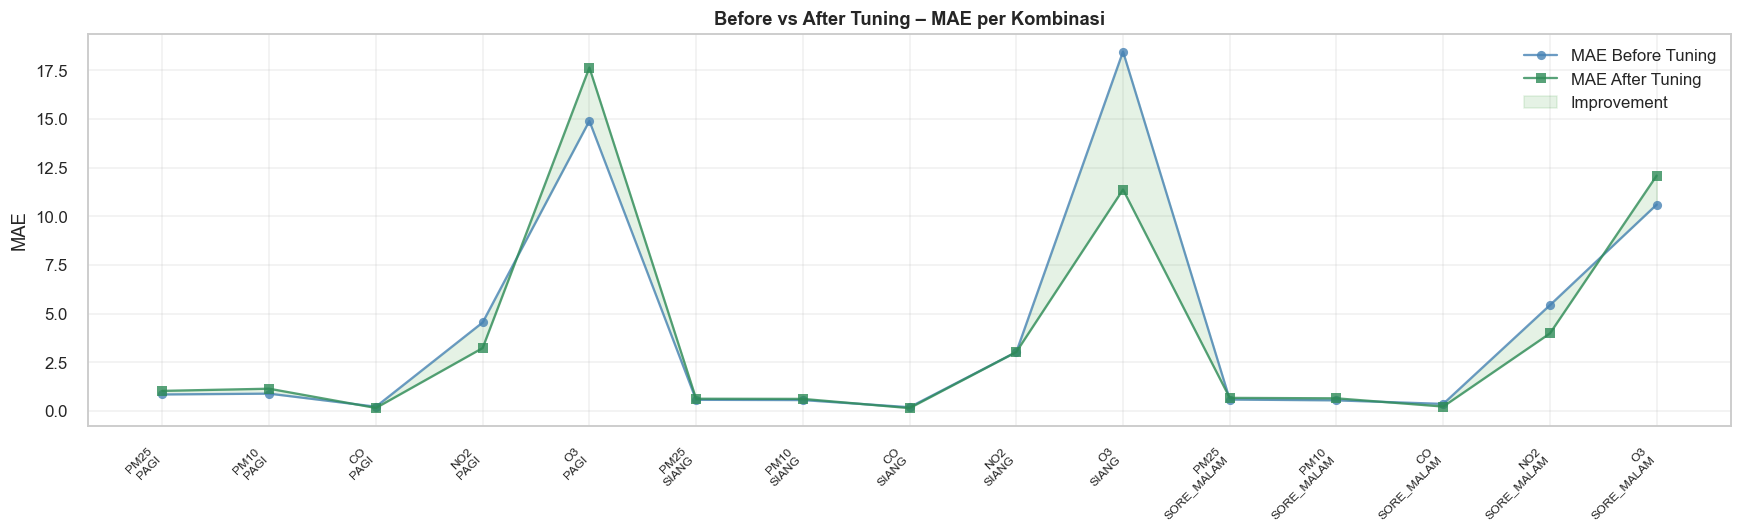

Disimpan -> reports/viz_before_after_tuning.png


In [14]:
# ── Viz 4: Before vs After Tuning MAE ────────────────────────────
df_rekap["combo"] = df_rekap["polutan"] + "\n" + df_rekap["segmen"]
x = range(len(df_rekap))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(x, df_rekap["mae_before"], marker="o",
        label="MAE Before Tuning",
        color="steelblue", linewidth=1.5, alpha=0.8)
ax.plot(x, df_rekap["mae_tuned"], marker="s",
        label="MAE After Tuning",
        color="seagreen", linewidth=1.5, alpha=0.8)
ax.fill_between(x, df_rekap["mae_before"], df_rekap["mae_tuned"],
                alpha=0.1, color="green", label="Improvement")
ax.set_xticks(x)
ax.set_xticklabels(df_rekap["combo"], rotation=45, ha="right", fontsize=8)
ax.set_title("Before vs After Tuning – MAE per Kombinasi", fontweight="bold")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/viz_before_after_tuning.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_before_after_tuning.png")

## 7. Analisis Teknis – Performa per Kombinasi

In [15]:
print("=" * 62)
print("ANALISIS TEKNIS – PERFORMA 15 KOMBINASI")
print("=" * 62)

best_combo  = df_rekap.loc[df_rekap["r2_tuned"].idxmax()]
worst_combo = df_rekap.loc[df_rekap["r2_tuned"].idxmin()]

print(f"\nKombinasi TERBAIK  (R2 tertinggi):")
print(f"  {best_combo['polutan']} x {best_combo['segmen']}")
print(f"  Model: {best_combo['model_terbaik']}")
print(f"  R2={best_combo['r2_tuned']:.4f}  MAE={best_combo['mae_tuned']:.4f}  RMSE={best_combo['rmse_tuned']:.4f}")

print(f"\nKombinasi TERSULIT (R2 terendah):")
print(f"  {worst_combo['polutan']} x {worst_combo['segmen']}")
print(f"  Model: {worst_combo['model_terbaik']}")
print(f"  R2={worst_combo['r2_tuned']:.4f}  MAE={worst_combo['mae_tuned']:.4f}  RMSE={worst_combo['rmse_tuned']:.4f}")

print(f"\nRata-rata R2 per Segmen:")
for seg in ["PAGI", "SIANG", "SORE_MALAM"]:
    avg = df_rekap[df_rekap["segmen"] == seg]["r2_tuned"].mean()
    print(f"  {seg:<14}: R2 = {avg:.4f}")

print(f"\nRata-rata R2 per Polutan:")
for pol in POLUTAN:
    avg = df_rekap[df_rekap["polutan"] == pol.upper()]["r2_tuned"].mean()
    print(f"  {pol.upper():<8}: R2 = {avg:.4f}")

print(f"\nModel yang paling sering jadi terbaik:")
for model, count in df_rekap["model_terbaik"].value_counts().items():
    print(f"  {model:<40}: {count}x dari 15 kombinasi")

# Tandai model outlier (R2 < 0.5)
outlier = df_rekap[df_rekap["r2_tuned"] < 0.5]
if not outlier.empty:
    print(f"\nModel Outlier (R2 < 0.5) — perlu perhatian:")
    for _, row in outlier.iterrows():
        print(f"  {row['polutan']} x {row['segmen']}: R2={row['r2_tuned']:.4f}")
else:
    print(f"\nTidak ada model outlier (semua R2 >= 0.5)")

ANALISIS TEKNIS – PERFORMA 15 KOMBINASI

Kombinasi TERBAIK  (R2 tertinggi):
  PM10 x SORE_MALAM
  Model: Lasso
  R2=0.9920  MAE=0.6545  RMSE=0.8840

Kombinasi TERSULIT (R2 terendah):
  O3 x SORE_MALAM
  Model: GradientBoostingRegressor
  R2=0.3565  MAE=12.0921  RMSE=15.9515

Rata-rata R2 per Segmen:
  PAGI          : R2 = 0.8369
  SIANG         : R2 = 0.8339
  SORE_MALAM    : R2 = 0.7827

Rata-rata R2 per Polutan:
  PM25    : R2 = 0.9839
  PM10    : R2 = 0.9822
  CO      : R2 = 0.7400
  NO2     : R2 = 0.7634
  O3      : R2 = 0.6197

Model yang paling sering jadi terbaik:
  Lasso                                   : 4x dari 15 kombinasi
  LGBMRegressor                           : 3x dari 15 kombinasi
  BayesianRidge                           : 3x dari 15 kombinasi
  ExtraTreesRegressor                     : 2x dari 15 kombinasi
  GradientBoostingRegressor               : 2x dari 15 kombinasi
  ElasticNet                              : 1x dari 15 kombinasi

Model Outlier (R2 < 0.5) — perl

## 8. Verifikasi File Model .pkl

In [16]:
print("=" * 55)
print("VERIFIKASI FILE MODEL .pkl")
print("=" * 55)

all_ok   = True
expected = []
for seg in SEGMEN:
    for pol in POLUTAN:
        expected.append(f"models/{pol}_{seg.lower()}_best.pkl")

for path in expected:
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "--"
    ikon   = "OK" if exists else "MISSING"
    if not exists:
        all_ok = False
    print(f"[{ikon}] {path:<50} {size}")

print()
if all_ok:
    print("Semua 15 model.pkl tersimpan dengan benar!")
else:
    print("Ada model yang belum tersimpan, cek ulang.")

VERIFIKASI FILE MODEL .pkl
[OK] models/pm25_pagi_best.pkl                          6.6 KB
[OK] models/pm10_pagi_best.pkl                          6.6 KB
[OK] models/co_pagi_best.pkl                            9064.8 KB
[OK] models/no2_pagi_best.pkl                           206.7 KB
[OK] models/o3_pagi_best.pkl                            8504.7 KB
[OK] models/pm25_siang_best.pkl                         23.3 KB
[OK] models/pm10_siang_best.pkl                         23.3 KB
[OK] models/co_siang_best.pkl                           183.2 KB
[OK] models/no2_siang_best.pkl                          236.3 KB
[OK] models/o3_siang_best.pkl                           23.4 KB
[OK] models/pm25_sore_malam_best.pkl                    6.6 KB
[OK] models/pm10_sore_malam_best.pkl                    6.6 KB
[OK] models/co_sore_malam_best.pkl                      290.4 KB
[OK] models/no2_sore_malam_best.pkl                     6.6 KB
[OK] models/o3_sore_malam_best.pkl                      187.9 KB

Semua 15

## 9. Ringkasan & Handover ke Tim

In [17]:
print("=" * 62)
print("RINGKASAN MINGGU 3 – LINDA ANGGARA WATI")
print("=" * 62)
print("""
TOLAK UKUR KEBERHASILAN MINGGU 3:

[OK] 15 model PyCaret dijalankan & tercatat di MLflow
     -> jalankan: mlflow ui  untuk lihat semua run

[OK] Tabel rekap model terbaik per parameter per segmen
     -> reports/rekap_15_model.csv
     -> reports/rekap_15_model.xlsx  (kirim ke Intan)

[OK] Semua 15 model.pkl tersimpan di models/
     Format: models/{polutan}_{segmen}_best.pkl

VISUALISASI (reports/):
   viz_r2_heatmap.png           heatmap R2 per polutan x segmen
   viz_mae_heatmap.png          heatmap MAE per polutan x segmen
   viz_model_frekuensi.png      model yang paling sering menang
   viz_before_after_tuning.png  before vs after tuning

HANDOVER KE INTAN:
   File  : reports/rekap_15_model.xlsx
   Kolom : polutan, segmen, model_terbaik, MAE, RMSE, R2
   Tolong masukkan ke tabel laporan BAB II
   Tulis narasi: model mana konsisten menang?

HANDOVER KE YUHANIDZ:
   Semua .pkl ada di models/ siap di-load FastAPI
   Naming: models/{polutan}_{segmen}_best.pkl
   Load  : load_model('models/pm25_pagi_best')  # tanpa .pkl
   Segmen: PAGI=06-11, SIANG=12-17, SORE_MALAM=18-05
""")

RINGKASAN MINGGU 3 – LINDA ANGGARA WATI

TOLAK UKUR KEBERHASILAN MINGGU 3:

[OK] 15 model PyCaret dijalankan & tercatat di MLflow
     -> jalankan: mlflow ui  untuk lihat semua run

[OK] Tabel rekap model terbaik per parameter per segmen
     -> reports/rekap_15_model.csv
     -> reports/rekap_15_model.xlsx  (kirim ke Intan)

[OK] Semua 15 model.pkl tersimpan di models/
     Format: models/{polutan}_{segmen}_best.pkl

VISUALISASI (reports/):
   viz_r2_heatmap.png           heatmap R2 per polutan x segmen
   viz_mae_heatmap.png          heatmap MAE per polutan x segmen
   viz_model_frekuensi.png      model yang paling sering menang
   viz_before_after_tuning.png  before vs after tuning

HANDOVER KE INTAN:
   File  : reports/rekap_15_model.xlsx
   Kolom : polutan, segmen, model_terbaik, MAE, RMSE, R2
   Tolong masukkan ke tabel laporan BAB II
   Tulis narasi: model mana konsisten menang?

HANDOVER KE YUHANIDZ:
   Semua .pkl ada di models/ siap di-load FastAPI
   Naming: models/{polutan}_

In [18]:
from datetime import datetime

# Buat tabel markdown
tabel_md = "| Parameter | Segmen | Model Terbaik | MAE | RMSE | R2 |\n"
tabel_md += "|:---:|:---:|:---|:---:|:---:|:---:|\n"
for _, row in df_rekap.iterrows():
    tabel_md += (f"| {row['polutan']} | {row['segmen']} "
                 f"| {row['model_terbaik']} "
                 f"| {row['mae_tuned']:.4f} "
                 f"| {row['rmse_tuned']:.4f} "
                 f"| {row['r2_tuned']:.4f} |\n")

handover = f"""# Handover Doc – Minggu 3 | Linda Anggara Wati

**Tanggal:** {datetime.today().strftime('%d %B %Y')}  
**Proyek:** Sistem Deteksi Anomali Kualitas Udara – Kelompok Aeris PENS 2026

---

## Tabel Rekap 15 Model (5 Polutan x 3 Segmen)

{tabel_md}

## File Output

| File | Keterangan |
|---|---|
| `models/{{polutan}}_{{segmen}}_best.pkl` | 15 model tersimpan |
| `reports/rekap_15_model.csv` | Tabel rekap CSV |
| `reports/rekap_15_model.xlsx` | Tabel rekap Excel (untuk Intan) |
| `reports/viz_r2_heatmap.png` | Heatmap R2 |
| `reports/viz_mae_heatmap.png` | Heatmap MAE |
| `reports/viz_model_frekuensi.png` | Frekuensi model terbaik |
| `reports/viz_before_after_tuning.png` | Before vs After tuning |

## Cara Load Model di FastAPI (untuk Yuhanidz)

```python
from pycaret.regression import load_model, predict_model
import pandas as pd

# Load model sesuai segmen jam saat ini
model = load_model('models/pm25_pagi_best')  # tanpa .pkl

# Prediksi
df_input = pd.DataFrame([{{...fitur...}}])
hasil    = predict_model(model, data=df_input)
prediksi = hasil['prediction_label'].values[0]
```

## Segmentasi Waktu
- **PAGI**: jam 06:00-11:59 -> load `models/{{polutan}}_pagi_best.pkl`
- **SIANG**: jam 12:00-17:59 -> load `models/{{polutan}}_siang_best.pkl`
- **SORE_MALAM**: jam 18:00-05:59 -> load `models/{{polutan}}_sore_malam_best.pkl`
"""

with open("reports/handover_minggu3_linda.md", "w", encoding="utf-8") as f:
    f.write(handover)

print("Handover doc -> reports/handover_minggu3_linda.md")
print("\nMinggu 3 selesai! Siap lanjut Minggu 4: Docker & Deployment.")

Handover doc -> reports/handover_minggu3_linda.md

Minggu 3 selesai! Siap lanjut Minggu 4: Docker & Deployment.
